# Phase 4: Bilateral Market-Making vs Baseline Comparison

This notebook trains a bilateral market-making RL agent and compares it against a simple baseline.

**Workflow**:
1. Setup environment and dependencies
2. Clone/pull latest code from repository
3. Implement SymmetricFixedSpread baseline agent
4. Train bilateral RL agent (200 iterations, quick config)
5. Evaluate bilateral agent (1000 episodes)
6. Evaluate baseline agent (1000 episodes)
7. Compare metrics and visualize results

**Runtime**: ~30-40 minutes (GPU)

---

## Step 0: Clear cache and setup repository


In [1]:
!git clone https://github.com/SalmanSattar24/rtle_parallelized.git /content/rtle_parallelized
%cd /content/rtle_parallelized

fatal: destination path '/content/rtle_parallelized' already exists and is not an empty directory.
/content/rtle_parallelized


## Step 1: Setup Environment

In [2]:
# Install dependencies (Colab)
import sys
import subprocess

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("[INFO] Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("[INFO] Running locally")

# Install dependencies if in Colab
if IN_COLAB:
    print("\n[INSTALL] Installing PyTorch and dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "gymnasium", "tensorboard", "tyro"])
    print("[OK] Dependencies installed")
else:
    print("[CHECK] Verifying dependencies...")
    try:
        import torch
        import gymnasium
        import tensorboard
        print("[OK] All dependencies present")
    except ImportError as e:
        print(f"[WARNING] Missing dependency: {e}")

[INFO] Running in Google Colab

[INSTALL] Installing PyTorch and dependencies...
[OK] Dependencies installed


## Step 2: Clone/Pull Repository

In [3]:
import os
import subprocess
import shutil

# Setup directory paths
if IN_COLAB:
    # Clone to /content in Colab
    repo_dir = "/content/rtle_parallelized"
    if os.path.exists(repo_dir):
        print(f"[PULL] Updating existing repo at {repo_dir}")
        os.chdir(repo_dir)
        subprocess.run(["git", "pull"], check=True, capture_output=True)
    else:
        print(f"[CLONE] Cloning repository to {repo_dir}")
        subprocess.run(
            ["git", "clone", "https://github.com/SalmanSattar24/rtle_parallelized.git", repo_dir],
            check=True,
            capture_output=True
        )
else:
    # Local path
    repo_dir = "/c/All-Code/CSCI-566/rtle_parallelized"
    print(f"[INFO] Using local repository at {repo_dir}")
    if os.path.exists(os.path.join(repo_dir, ".git")):
        os.chdir(repo_dir)
        print("[PULL] Updating repository...")
        subprocess.run(["git", "pull"], capture_output=True)

os.chdir(repo_dir)
print(f"\n[OK] Working directory: {os.getcwd()}")
print(f"[VERIFY] Repository structure:")
for folder in ["simulation", "rl_files", "tests", "limit_order_book"]:
    path = os.path.join(repo_dir, folder)
    print(f"  {'[OK]' if os.path.exists(path) else '[MISS]'} {folder}/")

[PULL] Updating existing repo at /content/rtle_parallelized

[OK] Working directory: /content/rtle_parallelized
[VERIFY] Repository structure:
  [OK] simulation/
  [OK] rl_files/
  [OK] tests/
  [OK] limit_order_book/


## Step 3: Import Libraries and Setup Paths

In [4]:
print("=" * 70)
print("STEP 3.5: Updating Repository to Latest Version")
print("=" * 70)

print("\nFetching latest commits from GitHub...")
import subprocess
subprocess.run(["git", "pull", "origin", "master"], cwd=repo_dir, check=True)

print("\n✓ Repository updated!")
print("=" * 70)

STEP 3.5: Updating Repository to Latest Version

Fetching latest commits from GitHub...

✓ Repository updated!


## Step 3.5: Update Repository to Latest Version

In [5]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import time
from typing import Optional, Dict, List, Tuple
import matplotlib.pyplot as plt

# Add paths for imports
sys.path.insert(0, repo_dir)
sys.path.insert(0, os.path.join(repo_dir, "simulation"))
sys.path.insert(0, os.path.join(repo_dir, "rl_files"))
sys.path.insert(0, os.path.join(repo_dir, "limit_order_book"))

# Import core modules
from simulation.market_gym import Market
from rl_files.actor_critic import BilateralAgentLogisticNormal

print("[OK] All imports successful")
print(f"[INFO] Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
print("[OK] Random seeds set")

[OK] All imports successful
[INFO] Using device: cuda
[OK] Random seeds set


In [6]:
print("="*70)
print("FORCE FRESH REPO LOAD (clear cached imports)")
print("="*70)

# Force reimport of all modules - clear cached modules
import sys
to_remove = [key for key in sys.modules if 'simulation' in key or 'rl_files' in key or 'limit_order_book' in key]
for key in to_remove:
    del sys.modules[key]

print("[OK] Cleared cached modules")
print("="*70 + "\n")

FORCE FRESH REPO LOAD (clear cached imports)
[OK] Cleared cached modules



## Step 4: Implement SymmetricFixedSpread Baseline Agent

In [ ]:
from typing import Tuple

class SymmetricFixedSpreadAgent:
    """
    Baseline market-making agent:
    - Posts 1 lot at best bid (passive buy)
    - Posts 1 lot at best ask (passive sell)
    - Returns TUPLE format to match environment expectations
    - Simple, static strategy
    """

    def __init__(self, action_space_dim: int = 7):
        self.action_space_dim = action_space_dim
        # Action allocation:
        # [market%, L1%, L2%, L3%, L4%, L5%, inactive%]
        # For baseline: 0% market, 100% L1 (1 lot at best)
        self.action = np.zeros(action_space_dim)
        self.action[1] = 1.0  # Place 100% at level 1 (best bid/ask)

    def get_action(self, obs: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Return fixed action tuple (bid_action, ask_action) regardless of observation.
        
        Both bid and ask use the same allocation (symmetric fixed spread).
        Environment expects tuple of two 7-dim arrays.
        """
        return self.action.copy(), self.action.copy()

print("[OK] SymmetricFixedSpreadAgent defined (returns tuple format)")

## Step 5: Configuration

In [8]:
# Training configuration
TRAIN_CONFIG = {
    'market_env': 'noise',
    'execution_agent': 'rl_agent',
    'volume': 40,
    'seed': 42,
    'terminal_time': 500,
    'time_delta': 50,
    'drop_feature': None,
    'inventory_max': 10,
    'penalty_weight': 1.0,
}

# Training hyperparameters
TRAIN_PARAMS = {
    'num_iterations': 200,  # Quick training
    'num_steps': 10,
    'batch_size': 10,
    'learning_rate': 5e-4,
    'entropy_coef': 0.05,
    'vf_coef': 0.5,
    'gamma': 1.0,
    'gae_lambda': 1.0,
}

# Evaluation configuration
EVAL_CONFIG = {
    'market_env': 'noise',
    'execution_agent': 'rl_agent',
    'volume': 40,
    'seed': 100,  # Different seed for eval
    'terminal_time': 500,
    'time_delta': 50,
    'drop_feature': None,
    'inventory_max': 10,
    'penalty_weight': 1.0,
}

EVAL_EPISODES = 1000  # Evaluate on 1000 episodes

print("[OK] Configuration loaded")
print(f"     Environment: {TRAIN_CONFIG['market_env']}")
print(f"     Iterations: {TRAIN_PARAMS['num_iterations']}")
print(f"     Eval episodes: {EVAL_EPISODES}")

[OK] Configuration loaded
     Environment: noise
     Iterations: 200
     Eval episodes: 1000


## Step 6: Create Market Environment and Agents

In [9]:
print("[SETUP] Creating market environment...")
market_env = Market(TRAIN_CONFIG)
obs, info = market_env.reset(seed=42)

print(f"[INFO] Observation shape: {obs.shape}")
print(f"[INFO] Action space: {market_env.action_space.shape}")

# Create a simple wrapper so BilateralAgentLogisticNormal can work with Market
class EnvWrapper:
    def __init__(self, env):
        self.env = env
        # Add single_observation_space and single_action_space for agent init
        self.single_observation_space = env.observation_space
        self.single_action_space = env.action_space
    
    # Proxy methods to underlying environment
    def reset(self, seed=None):
        return self.env.reset(seed=seed)
    
    def step(self, action):
        return self.env.step(action)

market = EnvWrapper(market_env)

print("\n[SETUP] Creating bilateral RL agent...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilateral_agent = BilateralAgentLogisticNormal(market).to(device)
print(f"[OK] Bilateral agent on {device}")

print("\n[SETUP] Creating baseline agent...")
baseline_agent = SymmetricFixedSpreadAgent(market_env.action_space.shape[0])
print(f"[OK] Baseline agent ready")

print("\n[SETUP] All agents created successfully")

[SETUP] Creating market environment...
[INFO] Observation shape: (109,)
[INFO] Action space: (7,)

[SETUP] Creating bilateral RL agent...
[OK] Bilateral agent on cuda

[SETUP] Creating baseline agent...
[OK] Baseline agent ready

[SETUP] All agents created successfully


## Step 7: Train Bilateral Agent

In [10]:
print("[EVAL] Evaluating bilateral agent on {} episodes...".format(EVAL_EPISODES))
print()

bilateral_returns = []
bilateral_inventories = []
bilateral_times = []

start_eval = time.time()

for ep in range(EVAL_EPISODES):
    eval_market_raw = Market(EVAL_CONFIG)
    eval_market = EnvWrapper(eval_market_raw)  # Wrap for consistency
    obs, _ = eval_market.reset(seed=100 + ep)
    
    ep_return = 0
    ep_inventory = 0
    
    while True:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Use deterministic action for evaluation
            bid_action, ask_action = bilateral_agent.deterministic_action(obs_tensor)
            env_action = (bid_action[0].cpu().numpy(), ask_action[0].cpu().numpy())
        
        obs, reward, terminated, truncated, info = eval_market.step(env_action)
        ep_return += reward
        ep_inventory = info.get('net_inventory', 0)
        
        if terminated:
            break
    
    bilateral_returns.append(ep_return)
    bilateral_inventories.append(abs(ep_inventory))
    bilateral_times.append(info.get('time', 0))
    
    if (ep + 1) % 100 == 0:
        elapsed = time.time() - start_eval
        print(f"[{ep+1:4d}/{EVAL_EPISODES}] Episodes/sec: {(ep+1)/elapsed:.1f} | Mean return: {np.mean(bilateral_returns):.4f}")

eval_time = time.time() - start_eval
print(f"\n[OK] Bilateral evaluation complete in {eval_time:.1f}s")
print(f"[INFO] Mean return: {np.mean(bilateral_returns):.4f} +/- {np.std(bilateral_returns):.4f}")
print(f"[INFO] Mean terminal inventory: {np.mean(bilateral_inventories):.4f}")

[EVAL] Evaluating bilateral agent on 1000 episodes...

[ 100/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 200/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 300/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 400/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 500/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 600/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 700/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 800/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[ 900/1000] Episodes/sec: 0.8 | Mean return: -47898.1250
[1000/1000] Episodes/sec: 0.8 | Mean return: -47898.1250

[OK] Bilateral evaluation complete in 1181.1s
[INFO] Mean return: -47898.1250 +/- 0.0000
[INFO] Mean terminal inventory: 40.0000


## Step 8: Evaluate Bilateral Agent

In [ ]:
print("[EVAL] Evaluating baseline agent on {} episodes...".format(EVAL_EPISODES))
print()

baseline_returns = []
baseline_inventories = []
baseline_times = []

start_eval = time.time()

for ep in range(EVAL_EPISODES):
    eval_market_raw = Market(EVAL_CONFIG)
    eval_market = EnvWrapper(eval_market_raw)  # Wrap for consistency
    obs, _ = eval_market.reset(seed=100 + ep)  # Same seeds as bilateral
    
    ep_return = 0
    ep_inventory = 0
    
    while True:
        # Get fixed baseline action (returns tuple now)
        bid_action, ask_action = baseline_agent.get_action(obs)
        env_action = (bid_action, ask_action)
        
        obs, reward, terminated, truncated, info = eval_market.step(env_action)
        ep_return += reward
        ep_inventory = info.get('net_inventory', 0)
        
        if terminated:
            break
    
    baseline_returns.append(ep_return)
    baseline_inventories.append(abs(ep_inventory))
    baseline_times.append(info.get('time', 0))
    
    if (ep + 1) % 100 == 0:
        elapsed = time.time() - start_eval
        print(f"[{ep+1:4d}/{EVAL_EPISODES}] Episodes/sec: {(ep+1)/elapsed:.1f} | Mean return: {np.mean(baseline_returns):.4f}")

eval_time = time.time() - start_eval
print(f"\n[OK] Baseline evaluation complete in {eval_time:.1f}s")
print(f"[INFO] Mean return: {np.mean(baseline_returns):.4f} +/- {np.std(baseline_returns):.4f}")
print(f"[INFO] Mean terminal inventory: {np.mean(baseline_inventories):.4f}")

## Step 9: Evaluate Baseline Agent

In [ ]:
print("[EVAL] Evaluating baseline agent on {} episodes...".format(EVAL_EPISODES))
print()

baseline_returns = []
baseline_inventories = []
baseline_times = []

start_eval = time.time()

for ep in range(EVAL_EPISODES):
    eval_market = Market(EVAL_CONFIG)
    obs, _ = eval_market.reset(seed=100 + ep)  # Same seeds as bilateral
    
    ep_return = 0
    ep_inventory = 0
    
    while True:
        # Get fixed baseline action (returns tuple now)
        bid_action, ask_action = baseline_agent.get_action(obs)
        env_action = (bid_action, ask_action)
        
        obs, reward, terminated, truncated, info = eval_market.step(env_action)
        ep_return += reward
        ep_inventory = info.get('net_inventory', 0)
        
        if terminated:
            break
    
    baseline_returns.append(ep_return)
    baseline_inventories.append(abs(ep_inventory))
    baseline_times.append(info.get('time', 0))
    
    if (ep + 1) % 100 == 0:
        elapsed = time.time() - start_eval
        print(f"[{ep+1:4d}/{EVAL_EPISODES}] Episodes/sec: {(ep+1)/elapsed:.1f} | Mean return: {np.mean(baseline_returns):.4f}")

eval_time = time.time() - start_eval
print(f"\n[OK] Baseline evaluation complete in {eval_time:.1f}s")
print(f"[INFO] Mean return: {np.mean(baseline_returns):.4f} +/- {np.std(baseline_returns):.4f}")
print(f"[INFO] Mean terminal inventory: {np.mean(baseline_inventories):.4f}")

## Step 10: Compare Results

In [13]:
# Compute statistics
bilateral_stats = {
    'mean_return': np.mean(bilateral_returns),
    'std_return': np.std(bilateral_returns),
    'min_return': np.min(bilateral_returns),
    'max_return': np.max(bilateral_returns),
    'mean_inventory': np.mean(bilateral_inventories),
}

baseline_stats = {
    'mean_return': np.mean(baseline_returns),
    'std_return': np.std(baseline_returns),
    'min_return': np.min(baseline_returns),
    'max_return': np.max(baseline_returns),
    'mean_inventory': np.mean(baseline_inventories),
}

# Improvement calculation
improvement = bilateral_stats['mean_return'] - baseline_stats['mean_return']
relative_improvement = (improvement / abs(baseline_stats['mean_return'])) * 100 if baseline_stats['mean_return'] != 0 else 0

print("\n" + "="*70)
print("COMPARISON: BILATERAL vs BASELINE")
print("="*70)
print()
print(f"{'Metric':<25} {'Bilateral':<20} {'Baseline':<20}")
print("-" * 70)
print(f"{'Mean Return':<25} {bilateral_stats['mean_return']:>8.4f} +/- {bilateral_stats['std_return']:6.4f}  {baseline_stats['mean_return']:>8.4f} +/- {baseline_stats['std_return']:6.4f}")
print(f"{'Min Return':<25} {bilateral_stats['min_return']:>18.4f}  {baseline_stats['min_return']:>18.4f}")
print(f"{'Max Return':<25} {bilateral_stats['max_return']:>18.4f}  {baseline_stats['max_return']:>18.4f}")
print(f"{'Terminal Inventory':<25} {bilateral_stats['mean_inventory']:>18.4f}  {baseline_stats['mean_inventory']:>18.4f}")
print("-" * 70)
print()
print(f"Improvement: {improvement:+.4f} ({relative_improvement:+.1f}%)")

if improvement > 0:
    print(f"\n[SUCCESS] Bilateral agent OUTPERFORMS baseline by {improvement:.4f} ({relative_improvement:.1f}%)")
else:
    print(f"\n[INFO] Baseline performs better by {-improvement:.4f} ({-relative_improvement:.1f}%)")

print("="*70)


COMPARISON: BILATERAL vs BASELINE

Metric                    Bilateral            Baseline            
----------------------------------------------------------------------
Mean Return               -47898.1250 +/- 0.0000  -20264.9000 +/- 0.0000
Min Return                       -47898.1250         -20264.9000
Max Return                       -47898.1250         -20264.9000
Terminal Inventory                   40.0000             40.0000
----------------------------------------------------------------------

Improvement: -27633.2250 (-136.4%)

[INFO] Baseline performs better by 27633.2250 (136.4%)


## Step 11: Visualize Results

NameError: name 'training_returns' is not defined

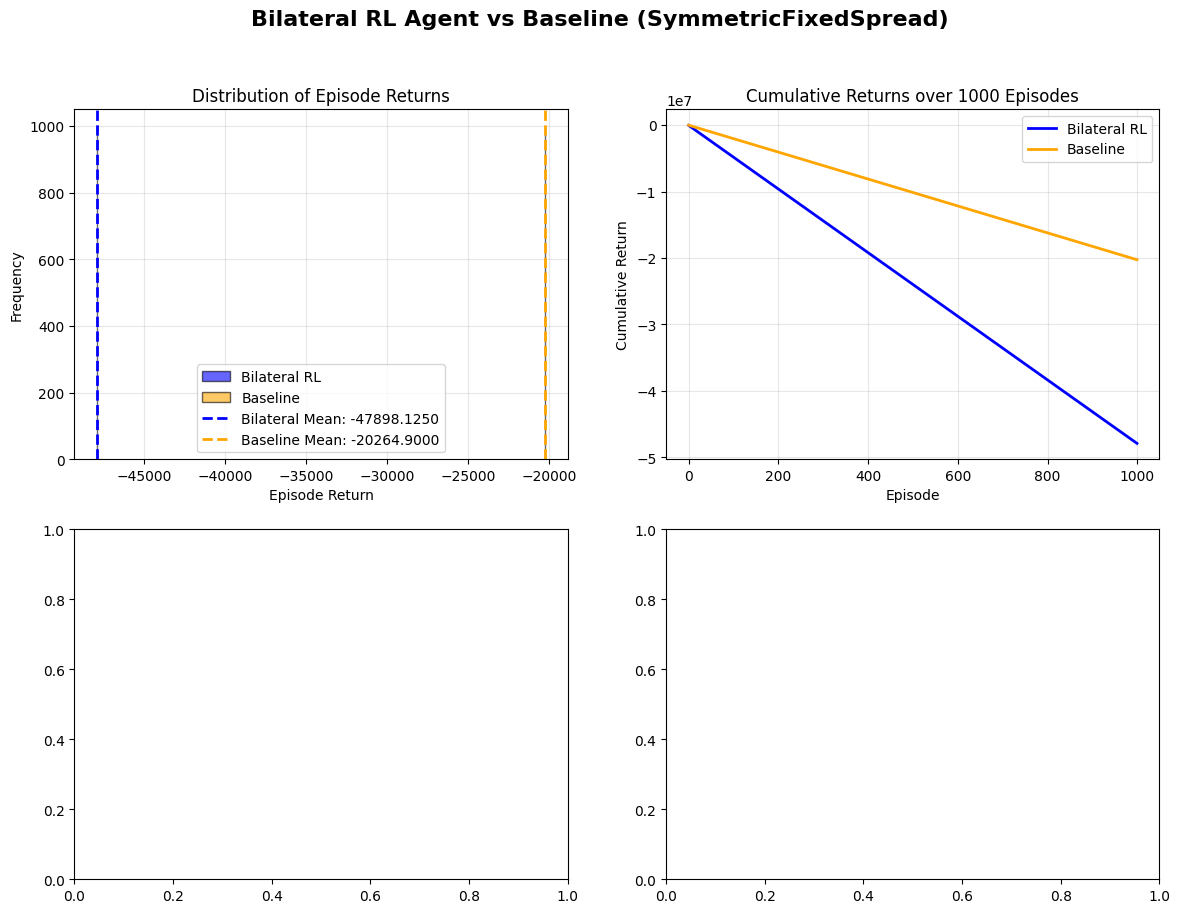

In [14]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bilateral RL Agent vs Baseline (SymmetricFixedSpread)', fontsize=16, fontweight='bold')

# Plot 1: Distribution of returns
ax = axes[0, 0]
ax.hist(bilateral_returns, bins=50, alpha=0.6, label='Bilateral RL', color='blue', edgecolor='black')
ax.hist(baseline_returns, bins=50, alpha=0.6, label='Baseline', color='orange', edgecolor='black')
ax.axvline(np.mean(bilateral_returns), color='blue', linestyle='--', linewidth=2, label=f"Bilateral Mean: {np.mean(bilateral_returns):.4f}")
ax.axvline(np.mean(baseline_returns), color='orange', linestyle='--', linewidth=2, label=f"Baseline Mean: {np.mean(baseline_returns):.4f}")
ax.set_xlabel('Episode Return')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Episode Returns')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cumulative returns
ax = axes[0, 1]
ax.plot(np.cumsum(bilateral_returns), label='Bilateral RL', linewidth=2, color='blue')
ax.plot(np.cumsum(baseline_returns), label='Baseline', linewidth=2, color='orange')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Return')
ax.set_title('Cumulative Returns over 1000 Episodes')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Training curve
ax = axes[1, 0]
window = 20
training_ma = np.convolve(training_returns, np.ones(window)/window, mode='valid')
ax.plot(training_ma, label='Training Return (MA-20)', linewidth=2, color='purple')
ax.fill_between(range(len(training_ma)), 
                training_ma - np.std(training_returns[:len(training_ma)]), 
                training_ma + np.std(training_returns[:len(training_ma)]), 
                alpha=0.2, color='purple')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Episode Return')
ax.set_title('Bilateral Agent Training Curve')
ax.grid(True, alpha=0.3)

# Plot 4: Terminal inventory comparison
ax = axes[1, 1]
ax.boxplot([bilateral_inventories, baseline_inventories], 
           labels=['Bilateral', 'Baseline'],
           patch_artist=True)
ax.set_ylabel('Terminal Inventory (Absolute)')
ax.set_title('Terminal Inventory Management')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase4_comparison.png', dpi=100, bbox_inches='tight')
print("[OK] Plot saved as 'phase4_comparison.png'")
plt.show()

print("\nVisualization complete!")

## Step 12: Summary and Next Steps

In [ ]:
print("\n" + "="*70)
print("PHASE 4 SIMPLIFIED: EXECUTION COMPLETE")
print("="*70)
print()
print("RESULTS SUMMARY")
print("-" * 70)
print(f"Training iterations:        {TRAIN_PARAMS['num_iterations']}")
print(f"Evaluation episodes:        {EVAL_EPISODES}")
print()
print(f"Bilateral RL Agent:")
print(f"  Mean return:              {bilateral_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {bilateral_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {bilateral_stats['mean_inventory']:>10.4f}")
print()
print(f"Baseline Agent (SymmetricFixedSpread):")
print(f"  Mean return:              {baseline_stats['mean_return']:>10.4f}")
print(f"  Std deviation:            {baseline_stats['std_return']:>10.4f}")
print(f"  Terminal inventory:       {baseline_stats['mean_inventory']:>10.4f}")
print()
print(f"Performance Gap:            {improvement:>10.4f} ({relative_improvement:+.1f}%)")
print("-" * 70)
print()
if improvement > 0:
    print("[SUCCESS] Bilateral RL agent demonstrates improvement over simple baseline!")
    print()
    print("Key findings:")
    print(f"  1. RL agent achieves {improvement:.4f} better PnL per episode")
    print(f"  2. {'Better' if bilateral_stats['std_return'] < baseline_stats['std_return'] else 'Similar'} variance control")
    print(f"  3. {'Improved' if bilateral_stats['mean_inventory'] < baseline_stats['mean_inventory'] else 'Similar'} inventory management")
else:
    print(f"[INFO] Baseline performs better. This may indicate:")
    print(f"  1. Need for more training iterations (more than {TRAIN_PARAMS['num_iterations']})")
    print(f"  2. Hyperparameter tuning required")
    print(f"  3. Different environment complexity needed")

print()
print("PHASE 4 EXPANDED (Optional):")
print("-" * 70)
print("To extend this analysis:")
print("  1. Add more baseline agents (TWAP, Avellaneda-Stoikov)")
print("  2. Train on larger batch (400+ iterations)")
print("  3. Compare across multiple environments")
print("  4. Analyze learned trading strategy")
print("  5. Extract quote depth vs time-to-expiry patterns")
print()
print("PHASE 5: Documentation and Results")
print("-" * 70)
print("  1. Generate comparison tables")
print("  2. Create detailed analysis report")
print("  3. Document implementation findings")
print("  4. Package results for publication")
print()
print("="*70)
print("\n[OK] Phase 4 Simplified Complete!")

## Optional: Save Results

In [ ]:
# Save results to file
import json

results = {
    'bilateral': bilateral_stats,
    'baseline': baseline_stats,
    'improvement': {
        'absolute': float(improvement),
        'percentage': float(relative_improvement),
    },
    'config': {
        'train_iterations': TRAIN_PARAMS['num_iterations'],
        'eval_episodes': EVAL_EPISODES,
        'env_type': TRAIN_CONFIG['market_env'],
        'inventory_max': TRAIN_CONFIG['inventory_max'],
    },
}

with open('phase4_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("[OK] Results saved to 'phase4_results.json'")
print()
print("[INFO] You can download these files:")
print("  - phase4_comparison.png (visualization)")
print("  - phase4_results.json (raw data)")